In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import pandas as pd

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

In [2]:
%matplotlib inline
import xarray as xr
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import sklearn
import sklearn.ensemble
import scipy.stats
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import xarray as xr
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import sklearn
import sklearn.ensemble
import scipy.stats
from sklearn.model_selection import train_test_split 
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

In [33]:
!pip install xeofs

In [39]:
#!pip install eofs
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from xeofs.xarray import EOF

In [35]:
#url = 'http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/noaa.ersst.v5/sst.mnmean.nc'
#ds = xr.open_dataset(url)
ds = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week11\sst.mnmean (2).nc")

# select period
ds = ds.sel(time=slice('1900', '2020'))

#actually load the data
ds.load()

ds_climo=ds.groupby('time.month').mean()
ds_anoms=ds.groupby('time.month')-ds_climo
ds_anoms
from scipy.signal import detrend
sst_anom_detrended = xr.apply_ufunc(detrend, ds_anoms.fillna(0),
                                    kwargs={'axis': 0}).where(~ds_anoms.isnull())
sst_anom_nino34 = sst_anom_detrended.sel(lat = slice(5, -5), lon = slice(190, 240)) 
sst_anom_nino34_mean = sst_anom_nino34.mean(dim = ('lon', 'lat'))
oni34 = sst_anom_nino34_mean.rolling(time = 3, center=True).mean()
nino34 = oni34.sel(time=slice('1900', '2019'))  

nino34.to_netcdf(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week15\nino34(1990~2019).nc")

PermissionError: [Errno 13] Permission denied: b'C:\\Users\\USER\\Desktop\\MA\\111-2\\CAD\\Week15\\nino34(1990~2019).nc'

In [ ]:
ds_anoms

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 1452, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1900-01-01 1900-02-01 ... 2020-12-01
    month      (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    sst        (time, lat, lon) float32 1.907e-06 1.907e-06 ... nan nan

In [57]:
# Create an EOF solver to do the EOF analysis. Square-root of cosine of
# latitude weights are applied before the computation of EOFs.
from xeofs.xarray import EOF
coslat = np.cos(np.deg2rad(ds_anoms.coords['lat'].values))
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = EOF(ds["sst"], weights=wgts)

# Retrieve the leading EOF, expressed as the correlation between the leading
# PC time series and the input SST anomalies at each grid point, and the
# leading PC time series itself.
eofs = solver.eofsAsCorrelation(neofs = 4)


ValueError: Expected shape (89, 180), but got (89, 1) instead.

In [31]:
model = EOF(ds_anoms["sst"], n_modes = 4, norm=False, dim='time')
model.solve()
expvar = model.explained_variance_ratio()
eofs = model.eofs()
pcs = model.pcs()

In [36]:
vars = solver.varianceFraction(neigs=4)

NameError: name 'solver' is not defined

In [37]:
vars

<function vars>

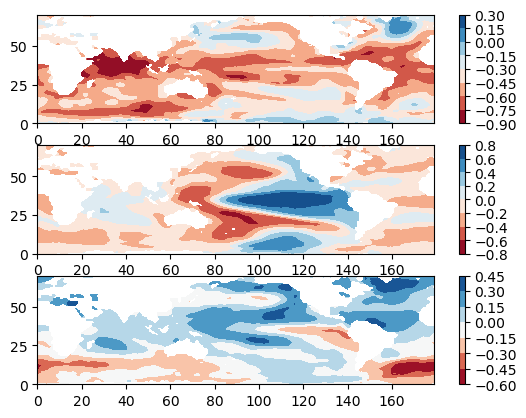

In [24]:
nrows=3
ncols=1
clevs=np.arange(-20,21,10)

for i in np.arange(3):
    plt.subplot(nrows,ncols,i+1)
    plt.contourf(eofs[i,:,:],cmap='RdBu')
    plt.colorbar()

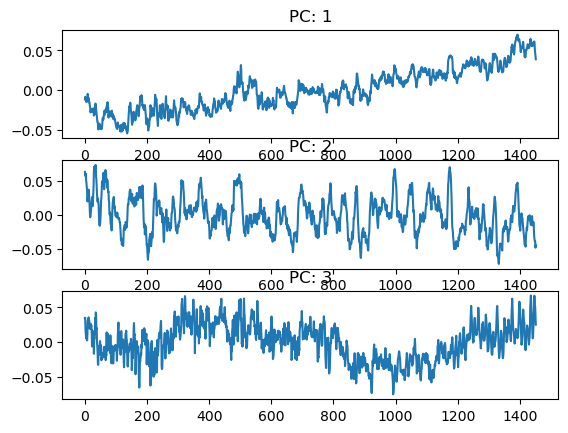

In [25]:
nrows=3
ncols=1
clevs=np.arange(-20,21,10)

for i in np.arange(3):
    plt.subplot(nrows,ncols,i+1)
    pcnorm = pcs[:,i]
    plt.title('PC: '+str(i+1))
    plt.plot(pcnorm)

In [36]:
mode_1 = pcs[:,0]

In [37]:
mode_2 = pcs[:,1]

In [38]:
mode_3 = pcs[:,2]

In [7]:
# check if ENSO index file is loaded
filename = r"C:\Users\USER\Desktop\MA\111-2\CAD\Week15\nino34(1990~2019).nc"
oni = xr.open_dataset(filename)
oni.head()

<xarray.Dataset>
Dimensions:    (time: 5, nbnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 1900-01-01 1900-02-01 ... 1900-05-01
    month      (time) int64 ...
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 ...
    sst        (time) float32 ...

In [8]:
nino34["sst"].head()

<xarray.DataArray 'sst' (time: 5)>
array([      nan, 1.6580681, 1.5254874, 1.4158939, 1.2907308],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1900-01-01 1900-02-01 ... 1900-05-01
    month    (time) int64 1 2 3 4 5

In [9]:
#Scaffold code to load in data.  This code cell is mostly data wrangling


def load_enso_indices():
  """
  Reads in the netcdf file to output a pandas Series of ENSO vals

  outputs
  -------

    pd.Series : monthly ENSO values starting from 1870-01-01
  """
  #read SST
  filename =r"C:\Users\USER\Desktop\MA\111-2\CAD\Week15\nino34(1990~2019).nc"
  ds_sst = xr.open_dataset(filename)
  ds_sst
  ds_sst = ds_sst.sel(time=slice('1900', '2019'))
  ds_sst.load()
  ts_nino34 = ds_sst["sst"].to_series()
  return ts_nino34

In [10]:
nino34
nino34 = nino34.sel(time=slice('1900', '2019'))
nino34.load()
ts_nino34 =  nino34["sst"].to_series()
ts_nino34

time
1900-01-01         NaN
1900-02-01    1.658068
1900-03-01    1.525487
1900-04-01    1.415894
1900-05-01    1.290731
                ...   
2019-08-01    0.210095
2019-09-01    0.260832
2019-10-01    0.422214
2019-11-01    0.551506
2019-12-01    0.521784
Name: sst, Length: 1440, dtype: float32

In [11]:
def assemble_predictors_predictands(start_date, end_date, lead_time, 
                                    dataset, data_format,
                                    num_input_time_steps=1,
                                    use_pca=False, n_components=32,
                                    lat_slice=None, lon_slice=None):
  """
  inputs
  ------

      start_date           str : the start date from which to extract sst
      end_date             str : the end date 
      lead_time            str : the number of months between each sst
                              value and the target Nino3.4 Index
      dataset              str : 'observations' 'CNRM' or 'MPI'
      data_format          str : 'spatial' or 'flatten'. 'spatial' preserves
                                  the lat/lon dimensions and returns an 
                                  array of shape (num_samples, num_input_time_steps,
                                  lat, lon).  'flatten' returns an array of shape
                                  (num_samples, num_input_time_steps*lat*lon)
      num_input_time_steps int : the number of time steps to use for each 
                                 predictor sample
      use_pca             bool : whether or not to apply principal components
                              analysis to the sst field
      n_components         int : the number of components to use for PCA
      lat_slice           slice: the slice of latitudes to use 
      lon_slice           slice: the slice of longitudes to use

  outputs
  -------
      Returns a tuple of the predictors (np array of sst temperature anomalies) 
      and the predictands (np array the ENSO index at the specified lead time).

  """
  file_name = {'observations' : r"C:\Users\USER\Desktop\MA\111-2\CAD\Week15\sst.mon.mean.trefadj.anom.1880to2018.nc",
               'CNRM'         : 'CNRM_tas_anomalies_regridded.nc',
               'MPI'          : 'MPI_tas_anomalies_regridded.nc'}[dataset]
  variable_name = {'observations' : 'sst',
                   'CNRM'         : 'tas',
                   'MPI'          : 'tas'}[dataset]
  ds = xr.open_dataset(file_name)
  sst = ds[variable_name].sel(time=slice(start_date, end_date))
  if lat_slice is not None:
    """YOUR CODE HERE"""
    raise NotImplementedError("If you desire, you must implement the slicing!")
  if lon_slice is not None:
    """YOUR CODE HERE"""
    raise NotImplementedError("If you desire, you must implement the slicing!")
  
  
  num_samples = sst.shape[0]
  #sst is a (num_samples, lat, lon) array
  #the line below converts it to (num_samples, num_input_time_steps, lat, lon)
  sst = np.stack([sst.values[n-num_input_time_steps:n] for n in range(num_input_time_steps,
                                                              num_samples+1)])
  #CHALLENGE: CAN YOU IMPLEMENT THE ABOVE LINE WITHOUT A FOR LOOP?
  num_samples = sst.shape[0]

  sst[np.isnan(sst)] = 0
  if data_format=='flatten':
    #sst is a 3D array: (time_steps, lat, lon)
    #in this tutorial, we will not be using ML models that take
    #advantage of the spatial nature of global temperature
    #therefore, we reshape sst into a 2D array: (time_steps, lat*lon)
    #(At each time step, there are lat*lon predictors)
    sst = sst.reshape(num_samples, -1)
    

    #Use Principal Components Analysis, also called
    #Empirical Orthogonal Functions, to reduce the
    #dimensionality of the array
    if use_pca:
      pca = sklearn.decomposition.PCA(n_components=n_components)
      pca.fit(sst)
      X = pca.transform(sst)
    else:
      X = sst
  else: # data_format=='spatial'
    X = sst

  start_date_plus_lead = pd.to_datetime(start_date) + \
                        pd.DateOffset(months=lead_time+num_input_time_steps-1)
  end_date_plus_lead = pd.to_datetime(end_date) + \
                      pd.DateOffset(months=lead_time)
  if dataset == 'observations':
    y = load_enso_indices()[slice(start_date_plus_lead, 
                                  end_date_plus_lead)]
  else: #the data is from a GCM
    X = X.astype(np.float32)
    #The Nino3.4 Index is composed of three month rolling values
    #Therefore, when calculating the Nino3.4 Index in a GCM
    #we have to extract the two months prior to the first target start date
    target_start_date_with_2_month = start_date_plus_lead - pd.DateOffset(months=2)
    subsetted_ds = ds[variable_name].sel(time=slice(target_start_date_with_2_month,
                                                   end_date_plus_lead))
    #Calculate the Nino3.4 index
    y = subsetted_ds.sel(lat=slice(5,-5), lon=slice(360-170,360-120)).mean(dim = ('lat','lon'))

    y = pd.Series(y.values).rolling(window=3).mean()[2:].values
    y = y.astype(np.float32)
  ds.close()
  return X.astype(np.float32), y.astype(np.float32)

In [12]:
def plot_nino_time_series(y, predictions, title):
  """
  inputs
  ------
    y           pd.Series : time series of the true Nino index
    predictions np.array  : time series of the predicted Nino index (same
                            length and time as y)
    titile                : the title of the plot

  outputs
  -------
    None.  Displays the plot
  """
  predictions = pd.Series(predictions, index=y.index)
  predictions = predictions.sort_index()
  y = y.sort_index()

  plt.plot(y, label='Ground Truth')
  plt.plot(predictions, '--', label='ML Predictions')
  plt.legend(loc='best')
  plt.title(title)
  plt.ylabel('Nino3.4 Index')
  plt.xlabel('Date')
  plt.show()
  plt.close()

In [13]:
"""Plot the performance of linear regression at 1 month ahead lead time"""
#1 month linear regression (lr) model
train_start_date = '1900-01-01'
train_end_date = '2005-12-31'
num_input_time_steps = 1
lead_time = 1 #change this and explore what happens!
train_predictors, train_predictands = assemble_predictors_predictands(train_start_date,
                      train_end_date, lead_time, 'observations', 'flatten', 
                      num_input_time_steps = num_input_time_steps,use_pca = True, n_components = 3)

test_predictors, test_predictands = assemble_predictors_predictands('2007-01-01',
                    '2017-12-31', lead_time, 'observations', 'flatten', 
                    num_input_time_steps=num_input_time_steps,use_pca = True, n_components = 3)

In [14]:
"""Plot the performance of linear regression at 1 month ahead lead time"""
#1 month linear regression (lr) model
train_start_date = '1900-01-01'
train_end_date = '2005-12-31'
num_input_time_steps = 1
lead_time = 1 #change this and explore what happens!
train_predictors, train_predictands = assemble_predictors_predictands(train_start_date,
                      train_end_date, lead_time, 'observations', 'flatten', 
                      num_input_time_steps = num_input_time_steps,use_pca = True, n_components = 3)

test_predictors, test_predictands = assemble_predictors_predictands('2007-01-01',
                    '2017-12-31', lead_time, 'observations', 'flatten', 
                    num_input_time_steps=num_input_time_steps,use_pca = True, n_components = 3)

In [15]:
# Here is the code segment to transform ENSO time series into the three label classes.
# neutral states as 0, La Nina as 1, El Nino as 2
_, y = assemble_predictors_predictands('1900-01-01','2005-12-31',1,'observations', 'flatten', 
                      num_input_time_steps = num_input_time_steps)

y_el_nino_binary = (train_predictands > 0.5).rolling(window=5).min()
y_la_nina_binary = (train_predictands < 0.5).rolling(window=5).min()
y_class_train = pd.Series(np.zeros(y_el_nino_binary.shape),
                     index=y.index)
y_class_train[y_el_nino_binary == 1.0] = 2 
y_class_train[y_la_nina_binary == 1.0] = 1 

In [16]:
# Here is the code segment to transform ENSO time series into the three label classes.
# neutral states as 0, La Nina as 1, El Nino as 2
_, y = assemble_predictors_predictands('2007-01-01','2017-12-31',1,'observations', 'flatten', 
                      num_input_time_steps=num_input_time_steps)

y_el_nino_binary = (test_predictands > 0.5).rolling(window=5).min()
y_la_nina_binary = (test_predictands < 0.5).rolling(window=5).min()
y_class_test = pd.Series(np.zeros(y_el_nino_binary.shape),
                     index=y.index)
y_class_test[y_el_nino_binary == 1.0] = 2 
y_class_test[y_la_nina_binary == 1.0] = 1 

In [17]:
train_predictors.shape

(1272, 3)

In [18]:
y_class_train.shape

(1272,)

In [19]:
from sklearn.ensemble import RandomForestClassifier

rfclassifier = RandomForestClassifier(n_estimators=10, criterion="entropy")

rfclassifier.fit(train_predictors, y_class_train)
y_rfpred = rfclassifier.predict(test_predictors)

In [210]:
# calculate the confusion matrix
from sklearn.metrics import f1_score, accuracy_score, mean_squared_error, r2_score
print(f"F1 Score: {round(f1_score(y_class_test, y_rfpred, average='macro'), 2)}")
print(f"Accuracy: {round(accuracy_score(y_class_test, y_rfpred), 2)}")

F1 Score: 0.34
Accuracy: 0.56


In [104]:
!pip install shap

In [58]:
import shap 
explainer = shap.Explainer(rfclassifier)
shap_test = explainer(test_predictors)
print(f"Shap values length: {len(shap_test)}\n")
print(f"Sample shap value:\n{shap_test[0]}")

Shap values length: 132

Sample shap value:
.values =
array([[ 0.01017341,  0.00791396, -0.01808737],
       [-0.18018588,  0.33425287, -0.15406699],
       [-0.03722023,  0.02615078,  0.01106945]])

.base_values =
array([0.2072327 , 0.63168239, 0.16108491])

.data =
array([  5.567736 , -47.594727 ,  -5.5344696], dtype=float32)


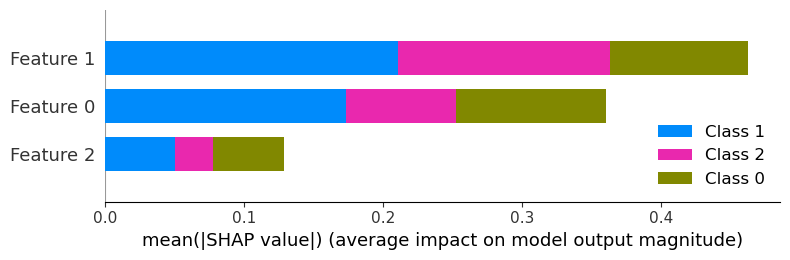

In [59]:
# Check global interpretability for the model.
shap_values = explainer.shap_values(test_predictors)
shap.summary_plot(shap_values, test_predictors)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


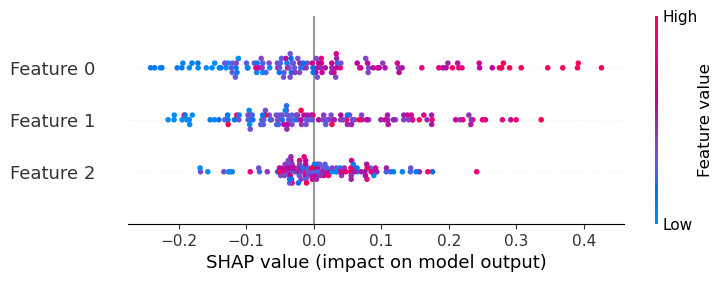

In [42]:
# Beeswarm plot for the 1st class:  'la nina'
shap.plots.beeswarm(shap_test[:,:,0])

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


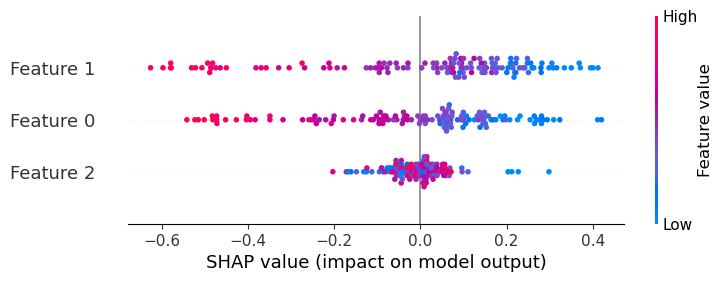

In [61]:
# Beeswarm plot for the 1st class:  'el nino'
shap.plots.beeswarm(shap_test[:,:,1])

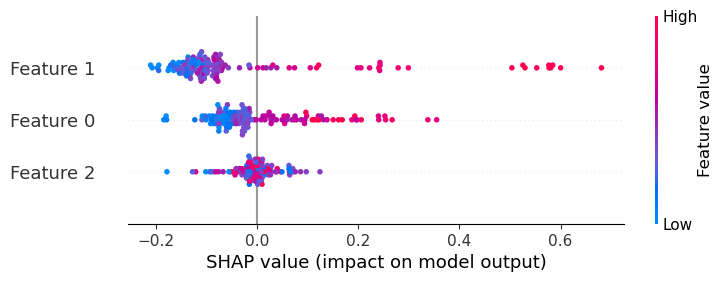

In [62]:
# Beeswarm plot for the 1st class:  'neutral'
shap.plots.beeswarm(shap_test[:,:,2])

(132, 3, 3)


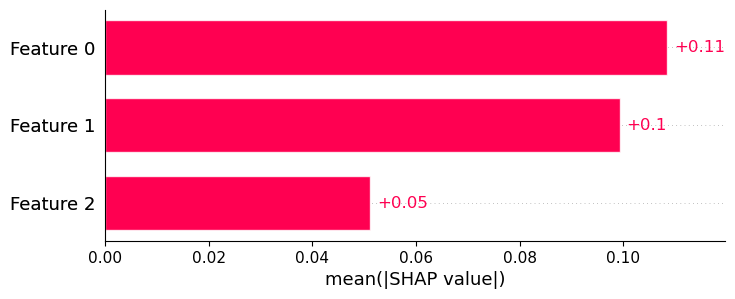

In [43]:
#shap_test(# of length, features, classification)
print(shap_test.shape)
# visualize the first prediction's explanation
#shap.plots.waterfall(shap_test[0])
#shap.summary_plot(shap_test.values)

# plot the impacts of each features on the 1st class: 'setosa'
shap.plots.bar(shap_test[:,:,0])

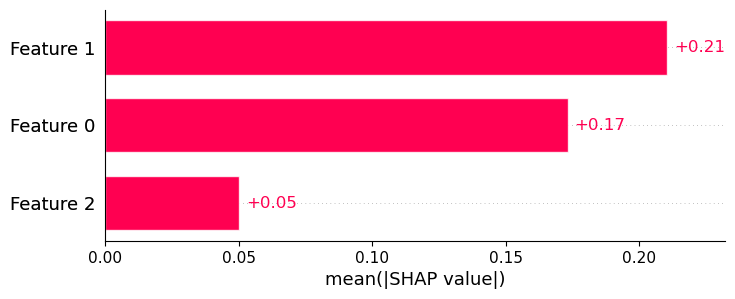

In [44]:
# plot the impacts of each features on the 2nd class: 'versicolor'
shap.plots.bar(shap_test[:,:,1])

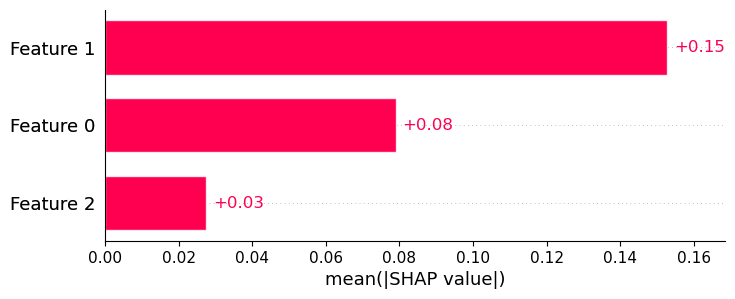

In [45]:
# plot the impacts of each features on the 3rd class: 'virginica'
shap.plots.bar(shap_test[:,:,2])

In [46]:
# create a dependence scatter plot to show the effect of a single feature across the first class, 'setosa'.
shap.plots.scatter(shap_test[:,:,0])

TypeError: object of type 'NoneType' has no len()

In [47]:
# 'versicolor'
shap.plots.scatter(shap_test[:,:,1])

TypeError: object of type 'NoneType' has no len()

In [48]:
#pd_shap = pd.DataFrame(shap_test.val3ues)
# shap_test: a tuple with 38 shapley elements; each element has 4 items; each item with 3 subitems.
print(len(shap_test))
#print(shap_test.values)
[len(a) for a in shap_test]

len(shap_test[:,:,0])

print(shap_test[0])

132
.values =
array([[ 0.01017341,  0.00791396, -0.01808737],
       [-0.18018588,  0.33425287, -0.15406699],
       [-0.03722023,  0.02615078,  0.01106945]])

.base_values =
array([0.2072327 , 0.63168239, 0.16108491])

.data =
array([  5.567736 , -47.594727 ,  -5.5344696], dtype=float32)


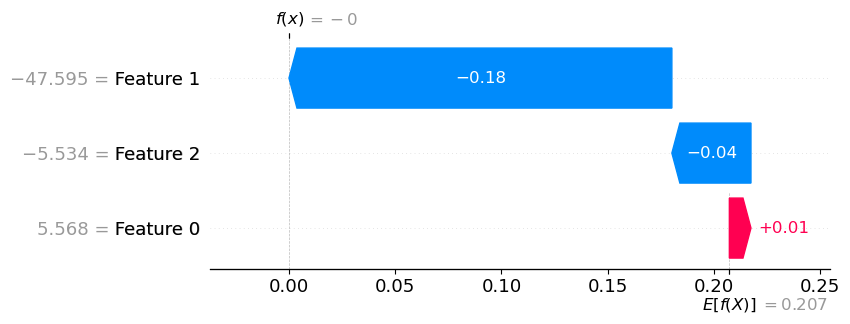

In [49]:

shap.plots.waterfall(shap_test[:,:,0][0])

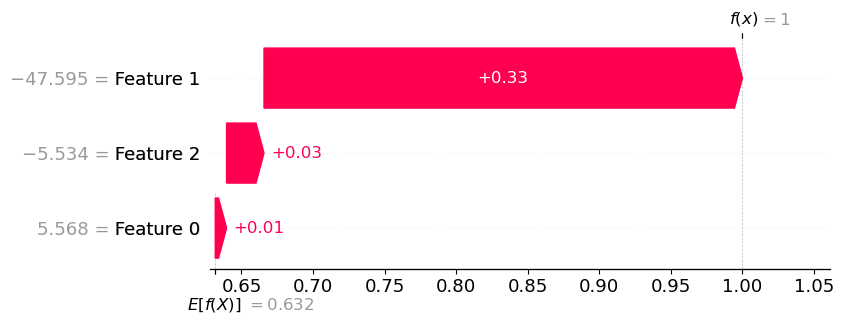

In [50]:

shap.plots.waterfall(shap_test[:,:,1][0])

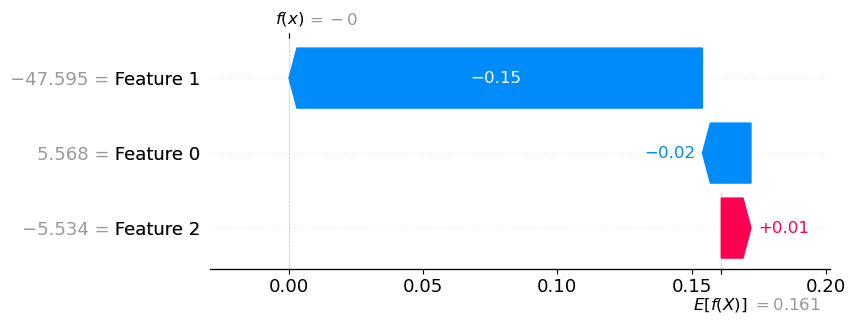

In [51]:
shap.plots.waterfall(shap_test[:,:,2][0])

In [53]:
shap.initjs()
#shap.force_plot(explainer.expected_value, shap_values[0], feature_names = explainer.data_feature_names)
shap.force_plot(explainer.expected_value[0], shap_values[0][0,:], test_predictors.iloc[0,:])

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [54]:
# print the JS visualization code to the notebook
shap.initjs()

# visualize all the training set predictions
shap.plots.force(explainer.expected_value[0], shap_values[0])

In [22]:
mode_1.plot()

NameError: name 'mode_1' is not defined

In [23]:
mode_2.plot()

NameError: name 'mode_2' is not defined

In [24]:
mode_3.plot()

NameError: name 'mode_3' is not defined